In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

tabular dyna-q

In [ ]:
STEPS = 500000
GAMMA = 1.0
ALPHA = 0.1
EPSILON = 0.05
N = 5

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]


#init q(s,a) = 0
q = np.zeros((21, 10, 2, 2)) #21x10x2x2 action-states
m = np.zeros((21, 10, 2, 2, 5)) #21x10x2 states, 2 actions, 4 r/s1_n/s2_n/s3_n/terminal
m_seen = np.zeros((21, 10, 2, 2), dtype=bool) 
seen_sa = []

#for episode in episodes
wins = []

#init s
s, _ = env.reset()
for steps in range(STEPS):
    #q learning step
    s1, s2, s3 = state_to_idx(s)
    
    #pick a as eps-greedy
    a = eps_greedy(q[s1, s2, s3], EPSILON)

    #get s', r from a
    s_n, r, term, trunc, info = env.step(a)
    s1_n, s2_n, s3_n = state_to_idx(s_n)

    if term or trunc:
        #update q, terminal q = 0
        q[s1, s2, s3, a] += ALPHA * (r - q[s1, s2, s3, a])
        wins.append(r > 0)
    else:
        #update q
        q[s1, s2, s3, a] += ALPHA * (r + GAMMA * np.max(q[s1_n, s2_n, s3_n]) - q[s1, s2, s3, a])
    
    #store in model
    m[s1, s2, s3, a] = [r, s1_n, s2_n, s3_n, 1.0 if (term or trunc) else 0.0]
    if not m_seen[s1, s2, s3, a]:
        m_seen[s1, s2, s3, a] = True
        seen_sa.append((s1, s2, s3, a))

    if term or trunc:
        s_n, _ = env.reset()

    #update s for next step
    s = s_n

    #planning step
    for i in range(N):
        #select random s, a
        s1_p, s2_p, s3_p, a_p = seen_sa[np.random.randint(len(seen_sa))]
        r_p, s1_n_p, s2_n_p, s3_n_p, terminal = m[s1_p, s2_p, s3_p, a_p]

        #model r, s' from s, a
        s1_n_p, s2_n_p, s3_n_p = int(s1_n_p), int(s2_n_p), int(s3_n_p)

        #q update
        if terminal:
            q[s1_p, s2_p, s3_p, a_p] += ALPHA * (r_p - q[s1_p, s2_p, s3_p, a_p])
        else:
            q[s1_p, s2_p, s3_p, a_p] += ALPHA * (r_p + GAMMA * np.max(q[s1_n_p, s2_n_p, s3_n_p]) - q[s1_p, s2_p, s3_p, a_p])

env.close()


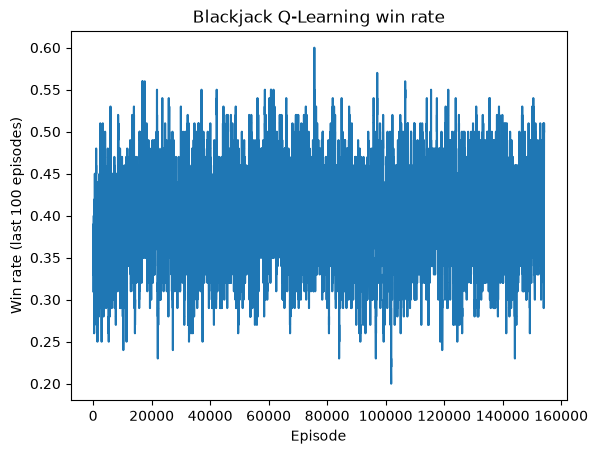

In [10]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack Q-Learning win rate')
plt.show()

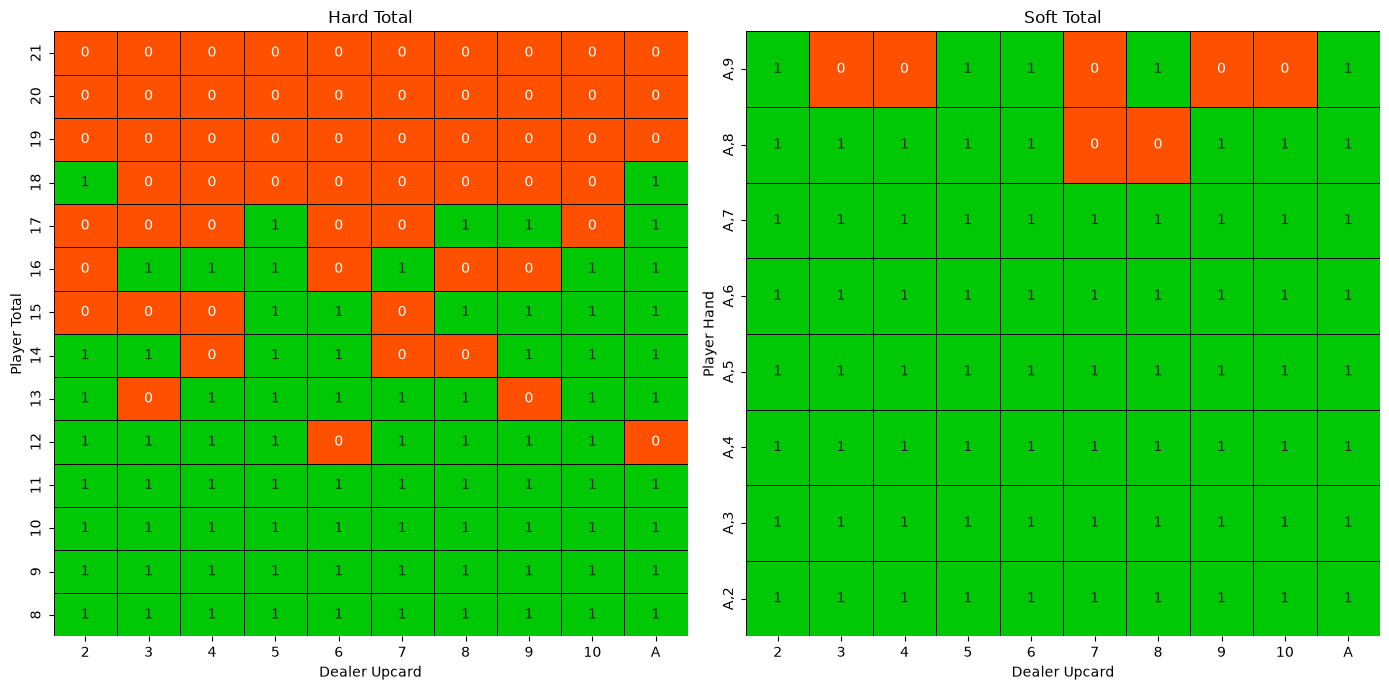

In [11]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 0]),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 1]),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()